I. Impliment linear regression


In [1]:
from __future__ import division, print_function, unicode_literals
import numpy as np
import matplotlib.pyplot as plt

-33.735410206298866 0.5592049619425978


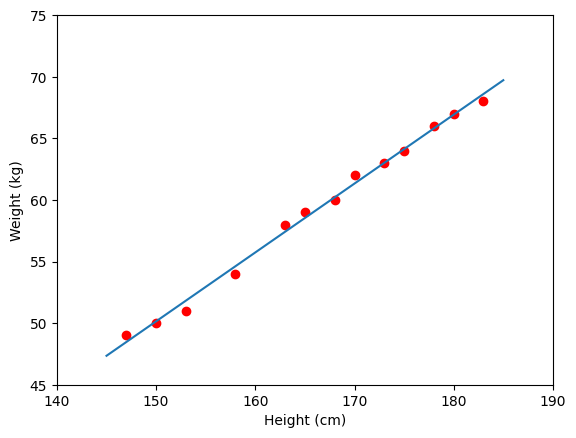

In [9]:
# nhap input
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T
y = np.array([[ 49, 50, 51,  54, 58, 59, 60, 62, 63, 64, 66, 67, 68]]).T

# tao Xbar
one = np.ones((X.shape[0],1))
Xbar = np.concatenate((one,X), axis = 1) #them cot 1 de co the tinh dc W0

A = np.dot(Xbar.T, Xbar) # tinh X^TX
B = np.dot (Xbar.T, y) # tinh X^T.y
W = np.dot(np.linalg.pinv(A),B)

w0 = W[0][0] # lay w0,w1
w1 = W[1][0]

x0 = np.linspace(145, 185, 100)
y0 = w0 + w1*x0

print(w0,w1)

# ve hinh
plt.plot(X.T, y.T, 'ro')     # data 
plt.plot(x0, y0)               # duong ve
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()






I. implement logistic regression

[[-4.092695  ]
 [ 1.55277242]]


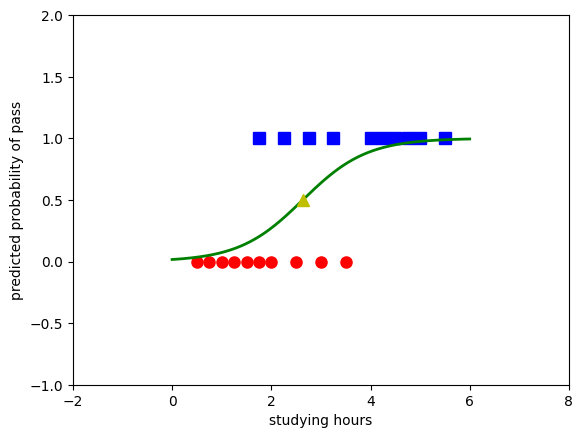

In [4]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals
import numpy as np 
import matplotlib.pyplot as plt
np.random.seed(2)

X = np.array([[0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 1.75, 2.00, 2.25, 2.50, 
              2.75, 3.00, 3.25, 3.50, 4.00, 4.25, 4.50, 4.75, 5.00, 5.50]])
y = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1])

# extended data 
X = np.concatenate((np.ones((1, X.shape[1])), X), axis = 0)

def sigmoid(s):
    return 1/(1 + np.exp(-s))

def logistic_sigmoid_regression(X, y, w_init, eta, tol = 1e-4, max_count = 10000):
    w = [w_init]    
    it = 0
    N = X.shape[1]
    d = X.shape[0]
    count = 0
    check_w_after = 20
    while count < max_count:
        # mix data 
        mix_id = np.random.permutation(N)
        for i in mix_id:
            xi = X[:, i].reshape(d, 1)
            yi = y[i]
            zi = sigmoid(np.dot(w[-1].T, xi))
            w_new = w[-1] + eta*(yi - zi)*xi
            count += 1
            # stopping criteria
            if count%check_w_after == 0:                
                if np.linalg.norm(w_new - w[-check_w_after]) < tol:
                    return w
            w.append(w_new)
    return w
eta = .05 
d = X.shape[0]
w_init = np.random.randn(d, 1)

w = logistic_sigmoid_regression(X, y, w_init, eta)
print(w[-1])

X0 = X[1, np.where(y == 0)][0]
y0 = y[np.where(y == 0)]
X1 = X[1, np.where(y == 1)][0]
y1 = y[np.where(y == 1)]

plt.plot(X0, y0, 'ro', markersize = 8)
plt.plot(X1, y1, 'bs', markersize = 8)

xx = np.linspace(0, 6, 1000)
w0 = w[-1][0][0]
w1 = w[-1][1][0]
threshold = -w0/w1
yy = sigmoid(w0 + w1*xx)
plt.axis([-2, 8, -1, 2])
plt.plot(xx, yy, 'g-', linewidth = 2)
plt.plot(threshold, .5, 'y^', markersize = 8)
plt.xlabel('studying hours')
plt.ylabel('predicted probability of pass')
plt.show()


II. implement linear regression


[13929872.64455245]
[10306582.37422079]
[7625999.18237673]
[5642849.69326854]
[4175675.71851866]
[3090230.83195734]
[2287196.82094014]
[1693096.06938209]
[1253568.35550934]
[928396.89128833]
[687828.48611463]
[509851.12972016]
[378179.89312088]
[280766.8575313]
[208698.72973386]
[155381.27570385]
[115935.94816237]
[86753.4994753]
[65163.7354763]
[49191.19268689]
[37374.38339803]
[28632.06953731]
[22164.32937972]
[17379.36470576]
[13839.35126131]
[11220.37783611]
[9282.80838638]
[7849.35533562]
[6788.85776037]
[6004.28016513]
[5423.83373397]
[4994.40765352]
[4676.70947326]
[4441.66984614]
[4267.78268312]
[4139.13734594]
[4043.96282366]
[3973.55068504]
[3921.4582571]
[3882.91912046]
[3854.40698198]
[3833.3130189]
[3817.70717153]
[3806.16154282]
[3797.61974572]
[3791.30024382]
[3786.62484071]
[3783.16577503]
[3780.60658031]
[3778.71312826]
[3777.31220606]
[3776.27566738]
[3775.50870698]
[3774.94118601]
[3774.52121437]
[3774.21040269]
[3773.98034975]
[3773.81004376]
[3773.68393976]
[3773.5

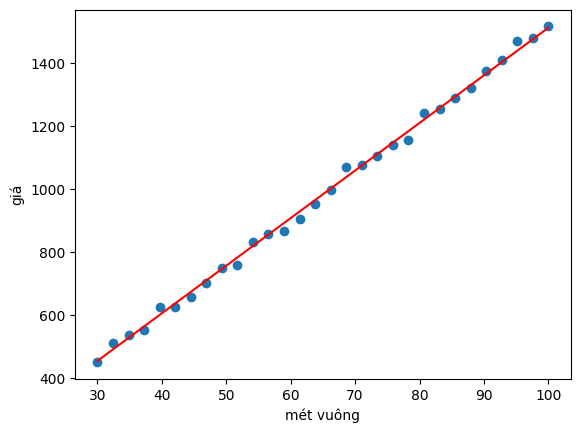

Giá nhà cho 50m^2 là :  [755.68795083]


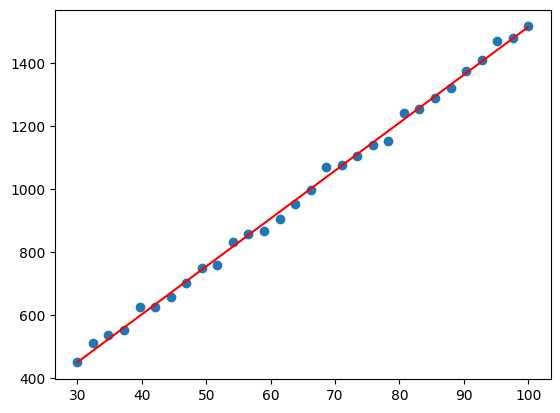

In [7]:
# -*- coding: utf-8 -*-

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Đọc dữ liệu
data = pd.read_csv('data_linear.csv').values
N = data.shape[0]

# Lấy cột diện tích và giá
x = data[:, 0].reshape(-1, 1)
y = data[:, 1].reshape(-1, 1)

# Vẽ dữ liệu
plt.scatter(x, y)
plt.xlabel('mét vuông')
plt.ylabel('giá')

# Thêm cột 1 để tính bias
x = np.hstack((np.ones((N, 1)), x))

# Khởi tạo trọng số
w = np.array([0., 1.]).reshape(-1, 1)

numOfIteration = 100
cost = np.zeros((numOfIteration, 1))
learning_rate = 0.000001

# Gradient Descent
for i in range(1, numOfIteration):
    
    r = np.dot(x, w) - y
    
    cost[i] = 0.5 * np.sum(r * r)
    
    w[0] -= learning_rate * np.sum(r)
    
    w[1] -= learning_rate * np.sum(np.multiply(r, x[:, 1].reshape(-1, 1)))
    
    print(cost[i])

# Dự đoán
predict = np.dot(x, w)

# Vẽ đường hồi quy
plt.plot((x[0][1], x[N-1][1]), (predict[0], predict[N-1]), 'r')
plt.show()

# Dự đoán giá nhà 50m2
x1 = 50
y1 = w[0] + w[1] * x1
print('Giá nhà cho 50m^2 là : ', y1)

# Lưu trọng số
np.save('weight.npy', w)

# Đọc lại trọng số
w = np.load('weight.npy')

# Linear Regression bằng sklearn
from sklearn.linear_model import LinearRegression

data = pd.read_csv('data_linear.csv').values

x = data[:, 0].reshape(-1, 1)
y = data[:, 1].reshape(-1, 1)

lrg = LinearRegression()

# Train model
lrg.fit(x, y)

# Dự đoán
y_pred = lrg.predict(x)

# Vẽ đường hồi quy
plt.scatter(x, y)
plt.plot((x[0], x[-1]), (y_pred[0], y_pred[-1]), 'r')
plt.show()

# Lưu tham số
np.savez('w2.npz', a=lrg.intercept_, b=lrg.coef_)

# Đọc lại tham số
k = np.load('w2.npz')
lrg.intercept_ = k['a']
lrg.coef_ = k['b']

II. Implement logistic regression

[61.54320979]
[25.26509737]
[15.91557397]
[15.98936358]
[15.52640441]
[15.5252128]
[15.05149857]
[14.97055546]
[14.53755163]
[14.38883584]
[14.01672764]
[13.81588095]
[13.50560402]
[13.26936357]
[13.01330438]
[12.75789968]
[12.54568219]
[12.28542017]
[12.10683743]
[11.85322903]
[11.6996333]
[11.46111425]
[11.32592096]
[11.1080137]
[10.9866925]
[10.79241716]
[10.68220455]
[10.51258415]
[10.41206607]
[10.2666262]
[10.17528201]
[10.05249233]
[9.97025903]
[9.8678978]
[9.79479722]
[9.71024181]
[9.64610635]
[9.57656408]
[9.52088693]
[9.46358307]
[9.41549993]
[9.36783326]
[9.32621432]
[9.28587962]
[9.24948444]
[9.21455341]
[9.18219012]
[9.15114239]
[9.12178478]
[9.09348983]
[9.06633217]
[9.03999439]
[9.01445064]
[8.98953603]
[8.96520454]
[8.94136696]
[8.91798298]
[8.89500168]
[8.87239303]
[8.85012594]
[8.82817878]
[8.80653096]
[8.7851665]
[8.76407052]
[8.74323059]
[8.72263511]
[8.70227388]
[8.68213732]
[8.66221671]
[8.64250384]
[8.62299106]
[8.60367117]
[8.58453738]
[8.56558327]
[8.54680276]


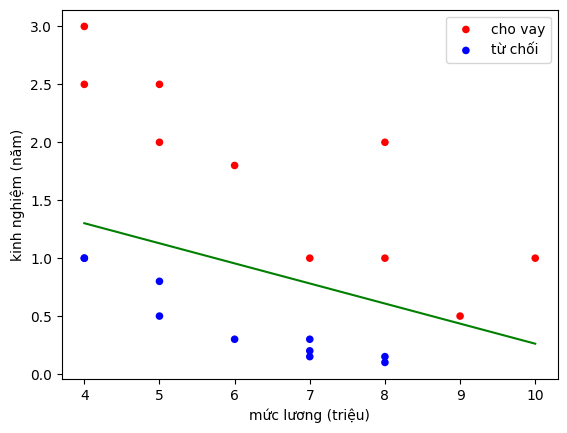

c:\Users\Lam\OneDrive\Desktop\practice ML\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


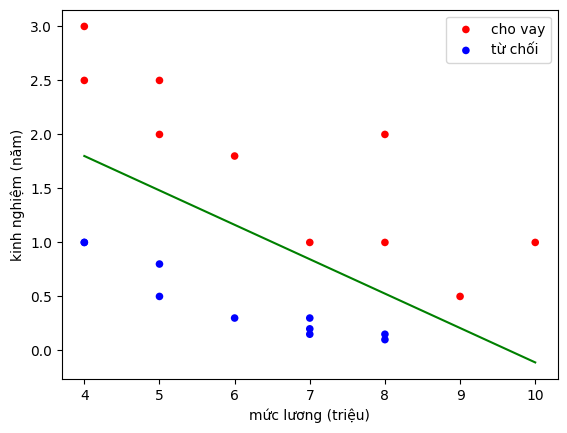

In [1]:
# -*- coding: utf-8 -*-

# Thêm thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Hàm sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# Load dữ liệu từ file csv
data = pd.read_csv('dataset.csv').values
N, d = data.shape

x = data[:, 0:d-1].reshape(-1, d-1)
y = data[:, 2].reshape(-1, 1)


# Vẽ dữ liệu
plt.scatter(x[:10, 0], x[:10, 1], c='red', edgecolors='none', s=30, label='cho vay')
plt.scatter(x[10:, 0], x[10:, 1], c='blue', edgecolors='none', s=30, label='từ chối')

plt.legend(loc=1)
plt.xlabel('mức lương (triệu)')
plt.ylabel('kinh nghiệm (năm)')


# Thêm cột 1 vào dữ liệu x
x = np.hstack((np.ones((N, 1)), x))

# Khởi tạo trọng số
w = np.array([0., 1., 0.1]).reshape(-1, 1)


# Số lần lặp
numOfIteration = 1000
cost = np.zeros((numOfIteration, 1))
learning_rate = 0.01


for i in range(1, numOfIteration):

    # Tính giá trị dự đoán
    y_predict = sigmoid(np.dot(x, w))

    # Tính cost
    cost[i] = -np.sum(
        np.multiply(y, np.log(y_predict)) +
        np.multiply(1 - y, np.log(1 - y_predict))
    )

    # Gradient descent
    w = w - learning_rate * np.dot(x.T, (y_predict - y))

    print(cost[i])


# Vẽ đường phân cách
t = 0.5

plt.plot(
    (4, 10),
    (
        -(w[0] + 4 * w[1] + np.log(1/t - 1)) / w[2],
        -(w[0] + 10 * w[1] + np.log(1/t - 1)) / w[2]
    ),
    'g'
)

plt.show()


# Lưu weight
np.save('weight_logistic.npy', w)

# Load weight
w = np.load('weight_logistic.npy')


# Logistic Regression bằng sklearn
from sklearn.linear_model import LogisticRegression


data = pd.read_csv('dataset.csv').values
N, d = data.shape

x = data[:, 0:d-1].reshape(-1, d-1)
y = data[:, 2].reshape(-1, 1)


# Vẽ dữ liệu
plt.scatter(x[:10, 0], x[:10, 1], c='red', edgecolors='none', s=30, label='cho vay')
plt.scatter(x[10:, 0], x[10:, 1], c='blue', edgecolors='none', s=30, label='từ chối')

plt.legend(loc=1)
plt.xlabel('mức lương (triệu)')
plt.ylabel('kinh nghiệm (năm)')


# Train model
logreg = LogisticRegression()
logreg.fit(x, y)


# Lưu các biến của mô hình
wg = np.zeros((3, 1))
wg[0:, 0] = logreg.intercept_
wg[1:, 0] = logreg.coef_


# Vẽ đường phân cách
t = 0.5

plt.plot(
    (4, 10),
    (
        -(wg[0] + 4 * wg[1] + np.log(1/t - 1)) / wg[2],
        -(wg[0] + 10 * wg[1] + np.log(1/t - 1)) / wg[2]
    ),
    'g'
)

plt.show()


# Lưu tham số
np.savez('w_logistic.npz', a=logreg.intercept_, b=logreg.coef_)

# Load lại tham số
k = np.load('w_logistic.npz')
logreg.intercept_ = k['a']
logreg.coef_ = k['b']